<a href="https://colab.research.google.com/github/Aritra0536G/Machine-Leaning-dengue-prediction/blob/main/day4_dengue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
d=pd.read_csv("/content/Dengue_diseases_dataset_modified (1).csv")

In [ ]:
d.head(10)

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1
5,61,Male,15.0,3300.0,1,1,34000.0,20.0,1
6,6,Child,11.0,2300.0,1,0,69000.0,12.5,1
7,21,Male,14.0,2500.0,1,1,77000.0,13.3,1
8,29,Male,15.0,2400.0,1,1,78000.0,14.5,1
9,31,Female,14.2,3700.0,0,1,82000.0,15.6,1


In [ ]:
d.shape

(989, 9)

In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          989 non-null    int64  
 1   gender                       989 non-null    object 
 2   hemoglobin_g_dl              989 non-null    float64
 3   wbc_count                    965 non-null    float64
 4   differential_count           989 non-null    int64  
 5   rbc_count                    989 non-null    int64  
 6   platelet_count               973 non-null    float64
 7   platelet_distribution_width  970 non-null    float64
 8   dengue_label                 989 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 69.7+ KB


In [ ]:
d.isnull().sum()

,0
age,0
gender,0
hemoglobin_g_dl,0
wbc_count,24
differential_count,0
rbc_count,0
platelet_count,16
platelet_distribution_width,19
dengue_label,0


In [ ]:
d.dropna(inplace=True)

In [ ]:
d.isnull().sum()

,0
age,0
gender,0
hemoglobin_g_dl,0
wbc_count,0
differential_count,0
rbc_count,0
platelet_count,0
platelet_distribution_width,0
dengue_label,0


In [ ]:
d.duplicated().sum()

np.int64(0)

**EDA**

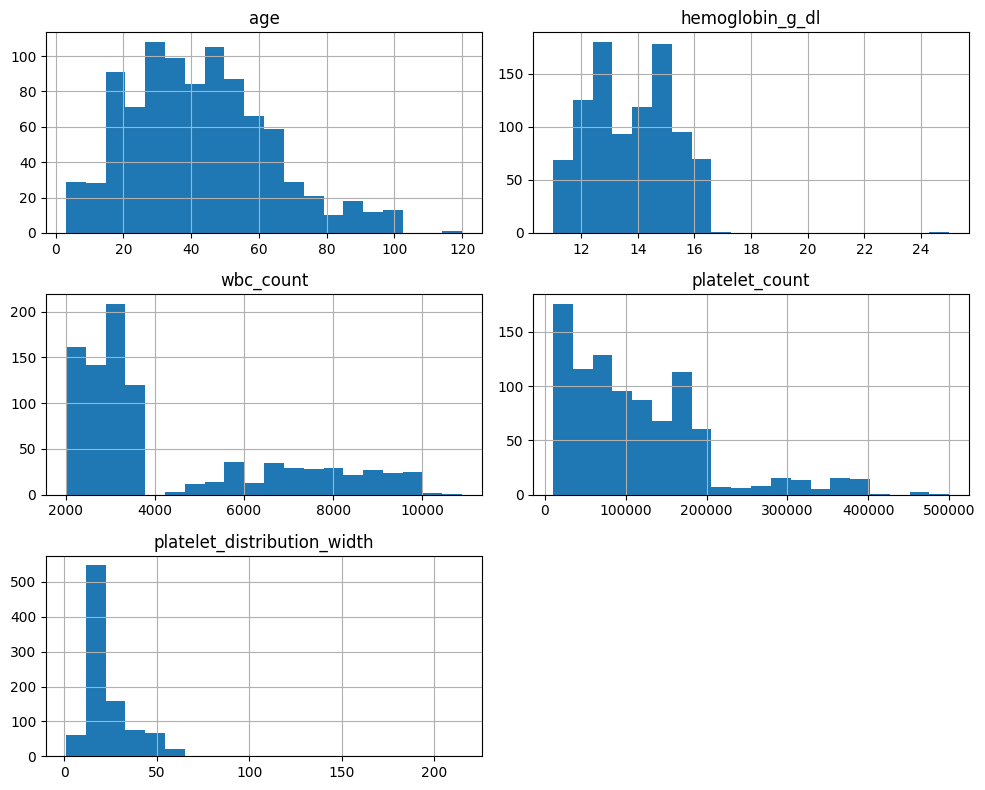

In [ ]:
import matplotlib.pyplot as plt

cols = [
    'age',
    'hemoglobin_g_dl',
    'wbc_count',
    'platelet_count',
    'platelet_distribution_width'
]

# Plot histograms
d[cols].hist(figsize=(10, 8), bins=20)

plt.tight_layout()
plt.show()

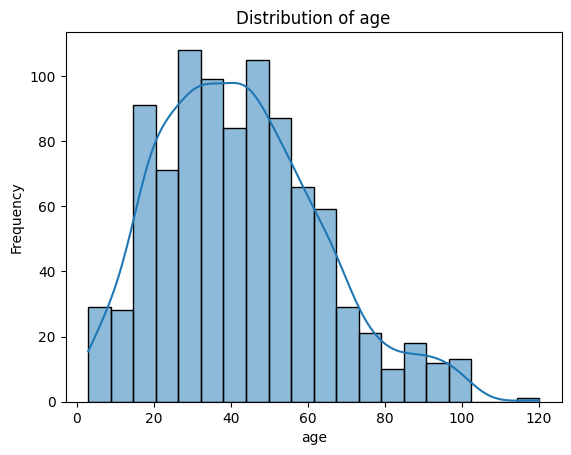

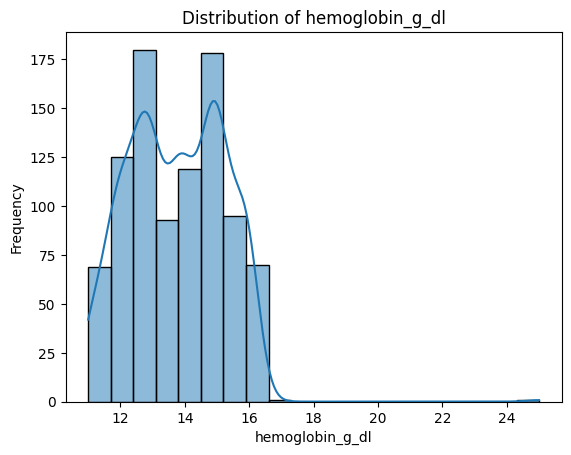

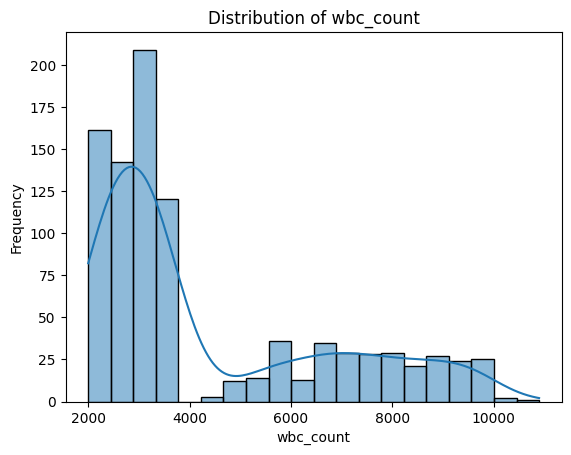

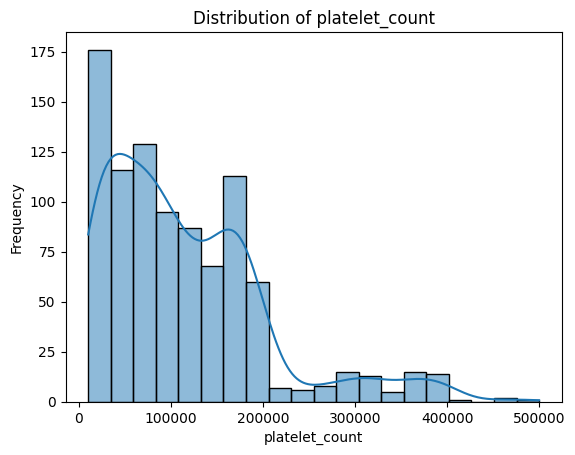

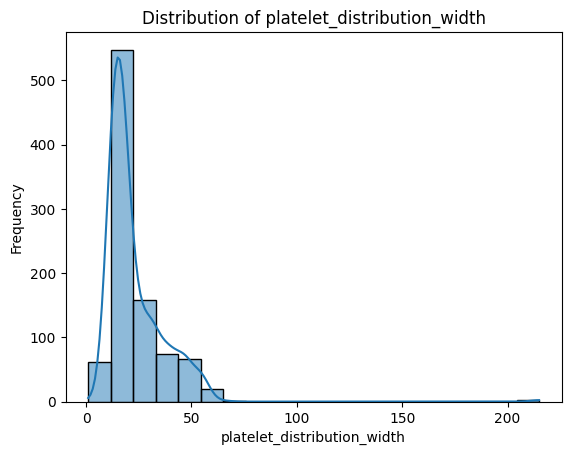

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'age',
    'hemoglobin_g_dl',
    'wbc_count',
    'platelet_count',
    'platelet_distribution_width'
]

for col in cols:
    plt.figure()
    sns.histplot(d[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

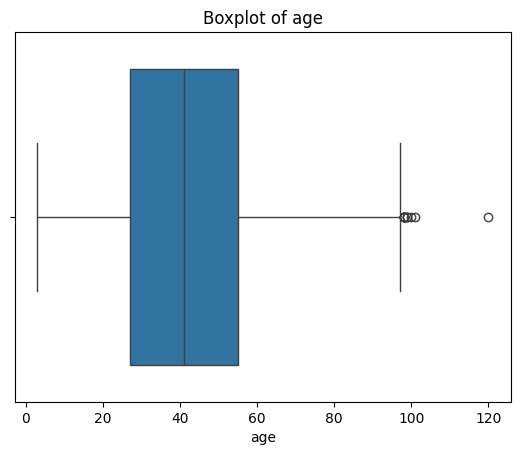

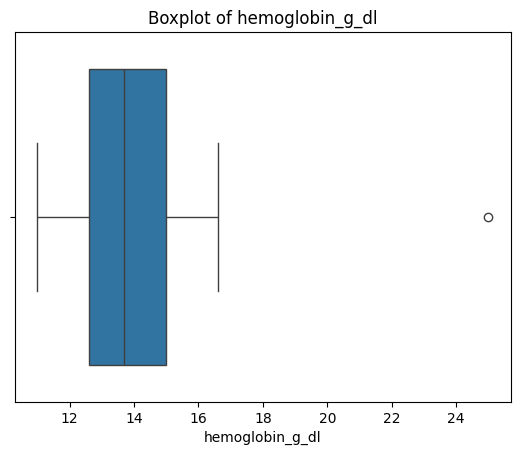

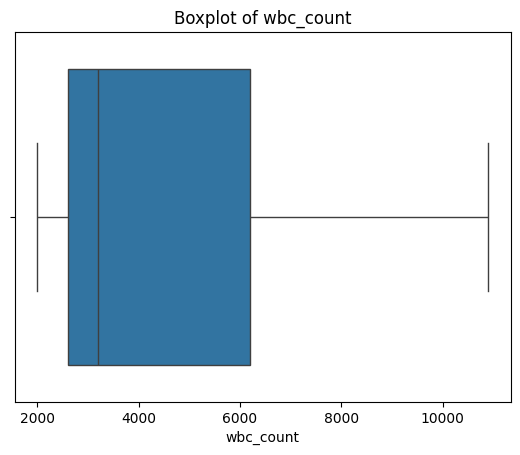

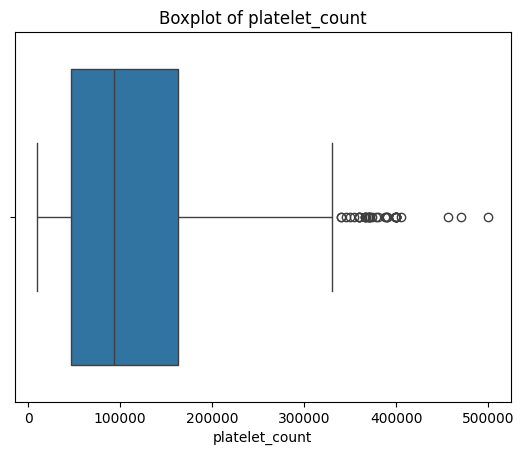

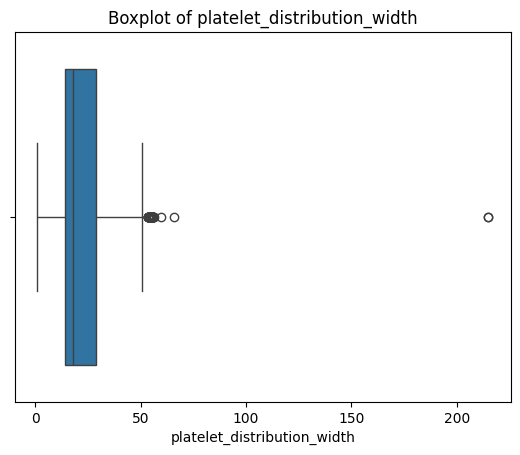

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'age',
    'hemoglobin_g_dl',
    'wbc_count',
    'platelet_count',
    'platelet_distribution_width'
]

for col in cols:
    plt.figure()
    sns.boxplot(x=d[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
d

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1
...,...,...,...,...,...,...,...,...,...
984,27,Female,11.6,9400.0,1,1,400000.0,39.9,0
985,19,Female,15.8,7400.0,1,1,320560.0,56.0,0
986,54,Female,11.9,7500.0,1,1,345000.0,44.4,0
987,34,Male,14.6,9500.0,1,1,326000.0,41.9,0


In [ ]:
catagorical=['gender']
len(catagorical)

1

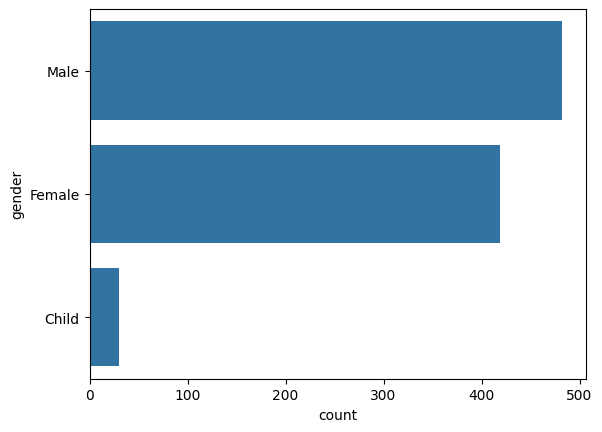

In [ ]:
sns.countplot(d['gender'])
plt.show()

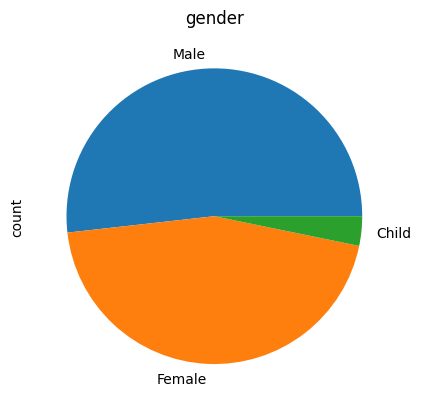

In [ ]:
d['gender'].value_counts().plot(kind='pie')
plt.title('gender')
plt.show()

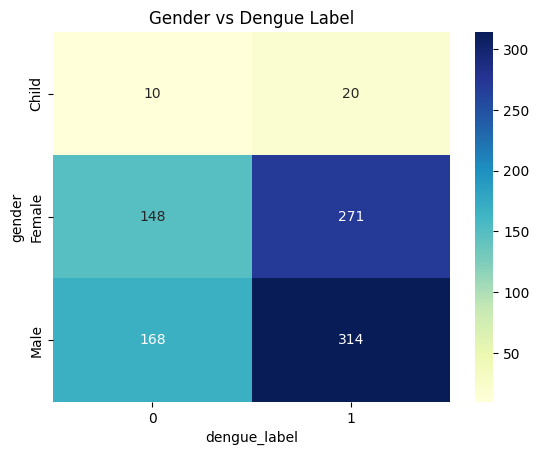

In [ ]:
sns.heatmap(pd.crosstab(d['gender'], d['dengue_label']), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Gender vs Dengue Label')
plt.show()

**PREPROCESSING**

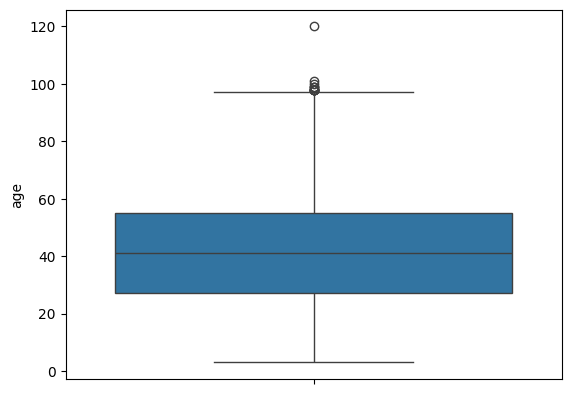

In [ ]:
sns.boxplot(d['age'])
plt.show()

In [ ]:
Q1 = d['age'].quantile(0.25)
Q3 = d['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d = d[(d['age'] >= lower) & (d['age'] <= upper)]

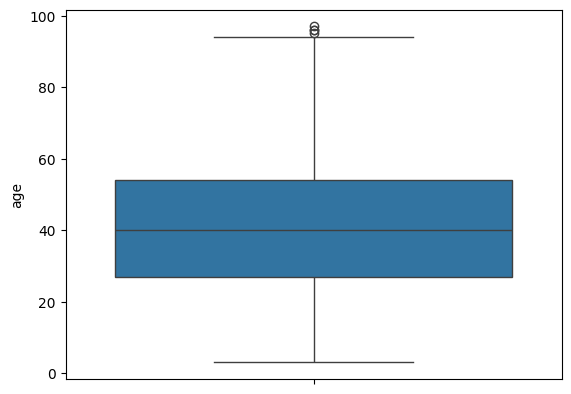

In [ ]:
sns.boxplot(d['age'])
plt.show()

In [ ]:
Q1 = d['age'].quantile(0.25)
Q3 = d['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d['age'] = d['age'].clip(lower, upper)

/tmp/ipykernel_12520/1977211822.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['age'] = d['age'].clip(lower, upper)


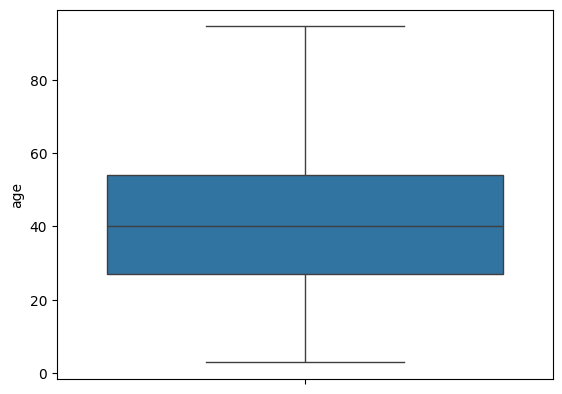

In [ ]:
sns.boxplot(d['age'])
plt.show()

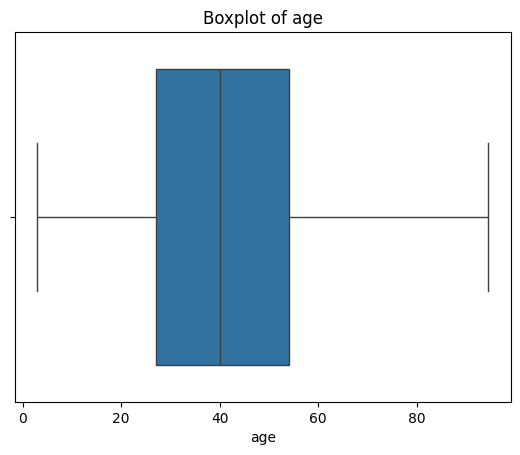

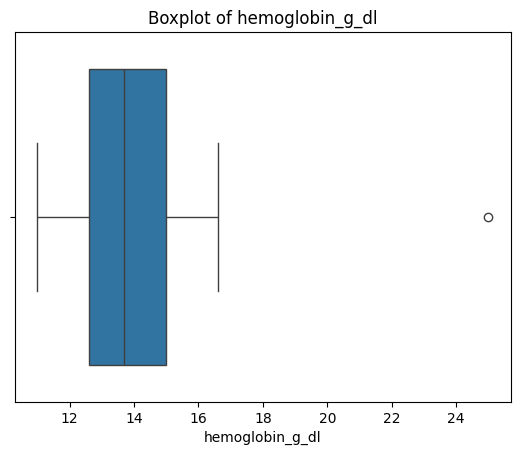

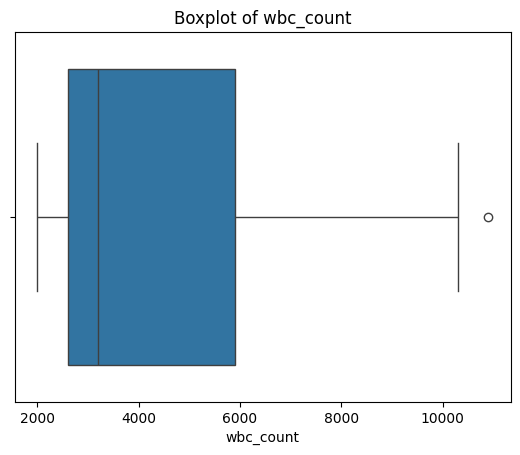

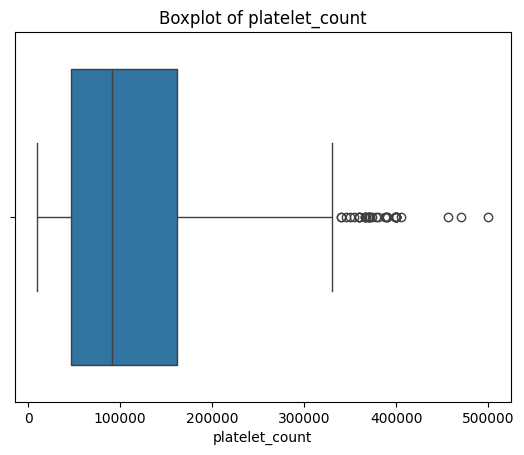

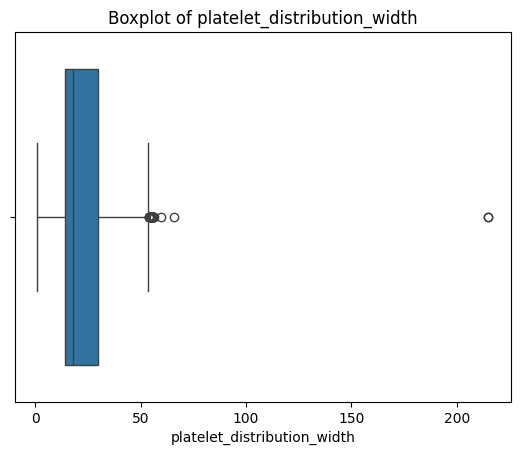

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'age',
    'hemoglobin_g_dl',
    'wbc_count',
    'platelet_count',
    'platelet_distribution_width'
]

for col in cols:
    plt.figure()
    sns.boxplot(x=d[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
Q1 = d['hemoglobin_g_dl'].quantile(0.25)
Q3 = d['hemoglobin_g_dl'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d['hemoglobin_g_dl'] = d['hemoglobin_g_dl'].clip(lower, upper)

/tmp/ipykernel_12520/3798732631.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['hemoglobin_g_dl'] = d['hemoglobin_g_dl'].clip(lower, upper)


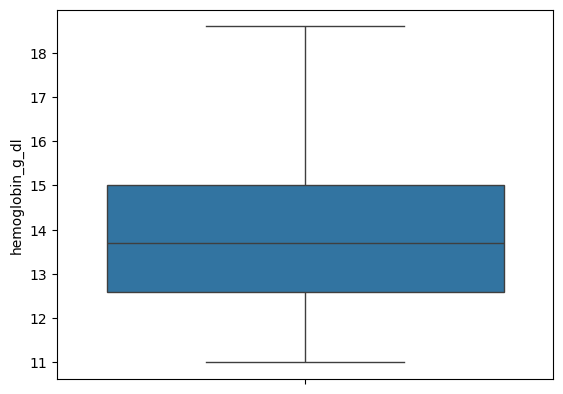

In [ ]:
sns.boxplot(d['hemoglobin_g_dl'])
plt.show()

In [ ]:
Q1 = d['wbc_count'].quantile(0.25)
Q3 = d['wbc_count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d['wbc_count'] = d['wbc_count'].clip(lower, upper)

/tmp/ipykernel_12520/1573154533.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['wbc_count'] = d['wbc_count'].clip(lower, upper)


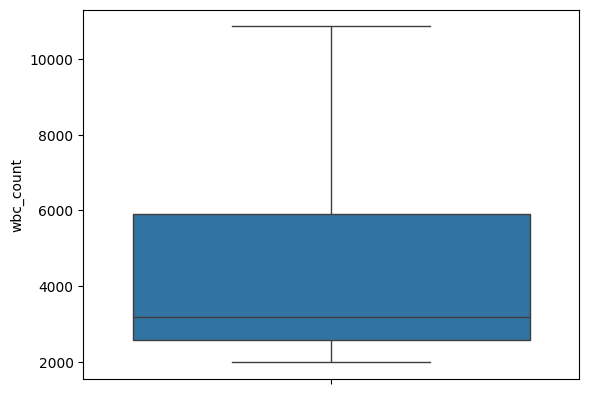

In [ ]:
sns.boxplot(d['wbc_count'])
plt.show()

In [ ]:
Q1 = d['platelet_count'].quantile(0.25)
Q3 = d['platelet_count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d['platelet_count'] = d['platelet_count'].clip(lower, upper)

/tmp/ipykernel_12520/3063426449.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['platelet_count'] = d['platelet_count'].clip(lower, upper)


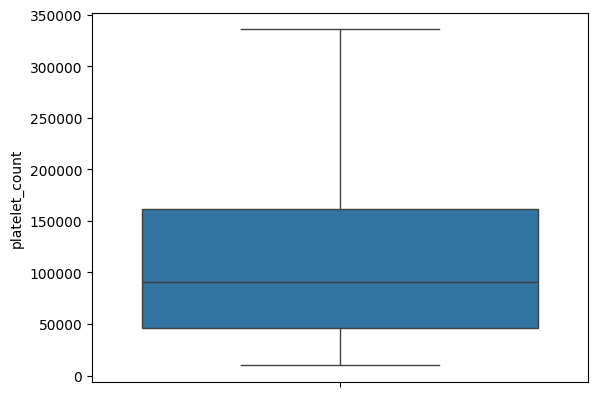

In [ ]:
sns.boxplot(d['platelet_count'])
plt.show()

In [ ]:
Q1 = d['platelet_distribution_width'].quantile(0.25)
Q3 = d['platelet_distribution_width'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

d['platelet_distribution_width'] = d['platelet_distribution_width'].clip(lower, upper)

/tmp/ipykernel_12520/2034103142.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d['platelet_distribution_width'] = d['platelet_distribution_width'].clip(lower, upper)


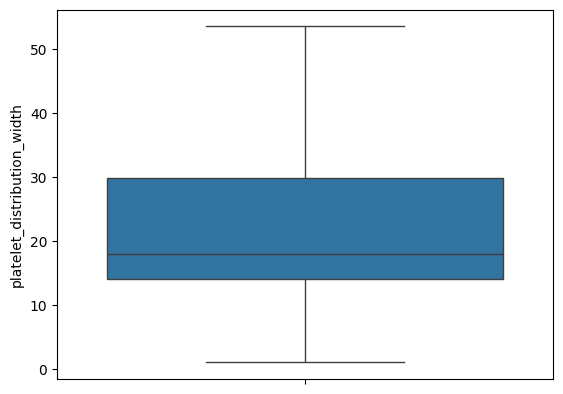

In [ ]:
sns.boxplot(d['platelet_distribution_width'])
plt.show()

In [ ]:
d

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43.0,Male,12.6,2200.0,1,1,62000.0,11.000,1
1,45.0,Male,13.2,3000.0,0,1,17000.0,17.000,1
2,50.0,Female,11.0,3300.0,1,1,19000.0,16.300,1
3,57.0,Female,11.9,3500.0,1,0,29000.0,14.000,1
4,51.0,Female,13.0,3100.0,0,1,30000.0,14.500,1
...,...,...,...,...,...,...,...,...,...
984,27.0,Female,11.6,9400.0,1,1,335687.5,39.900,0
985,19.0,Female,15.8,7400.0,1,1,320560.0,53.625,0
986,54.0,Female,11.9,7500.0,1,1,335687.5,44.400,0
987,34.0,Male,14.6,9500.0,1,1,326000.0,41.900,0


**SCALING**

In [ ]:
x=d.drop('dengue_label',axis=1)
y=d['dengue_label']

In [ ]:
x

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width
0,43.0,Male,12.6,2200.0,1,1,62000.0,11.000
1,45.0,Male,13.2,3000.0,0,1,17000.0,17.000
2,50.0,Female,11.0,3300.0,1,1,19000.0,16.300
3,57.0,Female,11.9,3500.0,1,0,29000.0,14.000
4,51.0,Female,13.0,3100.0,0,1,30000.0,14.500
...,...,...,...,...,...,...,...,...
984,27.0,Female,11.6,9400.0,1,1,335687.5,39.900
985,19.0,Female,15.8,7400.0,1,1,320560.0,53.625
986,54.0,Female,11.9,7500.0,1,1,335687.5,44.400
987,34.0,Male,14.6,9500.0,1,1,326000.0,41.900


In [ ]:
y

,dengue_label
0,1
1,1
2,1
3,1
4,1
...,...
984,0
985,0
986,0
987,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width
860,29.0,Male,15.0,3400.0,1,1,37900.0,12.6
26,47.0,Female,11.6,3400.0,1,1,43000.0,10.0
94,61.0,Male,14.0,3000.0,1,0,89000.0,18.9
10,37.0,Female,13.6,2300.0,1,0,81000.0,16.7
378,43.0,Male,14.9,3300.0,1,0,79000.0,19.4
...,...,...,...,...,...,...,...,...
119,21.0,Female,15.2,2900.0,0,1,57000.0,17.8
299,43.0,Female,11.0,2300.0,0,0,10000.0,24.8
928,61.0,Female,11.5,3300.0,1,1,135000.0,21.8
474,54.0,Female,13.7,2600.0,1,1,13590.0,12.8


In [ ]:
x_test

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width
728,69.0,Female,15.2,2200.0,1,1,40900.0,23.9
31,6.0,Child,15.0,2500.0,1,1,89000.0,13.3
412,27.0,Female,13.0,4900.0,1,1,150000.0,37.0
585,46.0,Female,12.6,2900.0,1,1,61000.0,19.0
872,54.0,Male,15.7,6800.0,1,1,185450.0,40.6
...,...,...,...,...,...,...,...,...
239,75.0,Male,13.8,9200.0,1,1,155000.0,13.3
810,54.0,Female,15.5,5800.0,1,1,178000.0,37.9
641,76.0,Female,15.0,6900.0,1,1,198765.0,17.0
948,46.0,Male,15.5,7500.0,1,1,280000.0,37.5


In [ ]:
y_train

,dengue_label
860,1
26,1
94,1
10,0
378,1
...,...
119,1
299,1
928,1
474,1


In [ ]:
y_test

,dengue_label
728,0
31,1
412,0
585,1
872,0
...,...
239,0
810,0
641,0
948,0


In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = make_column_transformer(
    (OneHotEncoder(drop='first'), ['gender']),   # only gender
    (StandardScaler(), [
        'age',
        'hemoglobin_g_dl',
        'wbc_count',
        'rbc_count',
        'platelet_count',
        'platelet_distribution_width'
    ])
)

In [ ]:
x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

In [ ]:
d

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43.0,Male,12.6,2200.0,1,1,62000.0,11.000,1
1,45.0,Male,13.2,3000.0,0,1,17000.0,17.000,1
2,50.0,Female,11.0,3300.0,1,1,19000.0,16.300,1
3,57.0,Female,11.9,3500.0,1,0,29000.0,14.000,1
4,51.0,Female,13.0,3100.0,0,1,30000.0,14.500,1
...,...,...,...,...,...,...,...,...,...
984,27.0,Female,11.6,9400.0,1,1,335687.5,39.900,0
985,19.0,Female,15.8,7400.0,1,1,320560.0,53.625,0
986,54.0,Female,11.9,7500.0,1,1,335687.5,44.400,0
987,34.0,Male,14.6,9500.0,1,1,326000.0,41.900,0


In [ ]:
x_train

array([[ 0.        ,  1.        , -0.6273062 , ...,  0.26452003,
        -0.89731625, -0.8550231 ],
       [ 1.        ,  0.        ,  0.26762626, ...,  0.26452003,
        -0.83682385, -1.07445688],
       [ 0.        ,  1.        ,  0.96368484, ..., -3.78043207,
        -0.29120611, -0.32331816],
       ...,
       [ 1.        ,  0.        ,  0.96368484, ...,  0.26452003,
         0.25441164, -0.07856509],
       [ 1.        ,  0.        ,  0.61565555, ...,  0.26452003,
        -1.18566336, -0.83814358],
       [ 0.        ,  0.        , -1.82054948, ...,  0.26452003,
        -0.8486851 , -0.61027003]])

In [ ]:
y_train

,dengue_label
860,1
26,1
94,1
10,0
378,1
...,...
119,1
299,1
928,1
474,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
M=RandomForestClassifier()
M.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=M.predict(x_test)
accuracy_score(y_test,y_pred)

0.907608695652174